Using data directory: ..\data
Metadata → center=(552.0,330.0) taskRadius=209.5 taskTolerance=47.0

--- Diagnostics ---
Raw samples: 19593
Time ms min/max: 0 / 1616776892427
Inside flag distribution: (array([False,  True]), array([  765, 18828]))
Markers count: 14
First 5 markers: [(np.float64(1616776712325.0), np.str_('KeyTyped=32 DoCycleChange')), (np.float64(1616776712331.0), np.str_('DoCycleChange:DoStartCycleTimedSequence')), (np.float64(1616776712333.0), np.str_('DoCycleChange:DoRecord RecordDone=0 PauseDone=0 ToDo=6')), (np.float64(1616776732336.0), np.str_('DoCycleChange:DoPause RecordDone=1 PauseDone=0 ToDo=6')), (np.float64(1616776752340.0), np.str_('DoCycleChange:DoRecord RecordDone=1 PauseDone=1 ToDo=6'))]

Recording intervals (5):
  Rec 1: 0.000s → 20.003s (dur 20.003s) points=3971
  Rec 2: 40.007s → 60.018s (dur 20.011s) points=3898
  Rec 3: 80.039s → 100.053s (dur 20.014s) points=3898
  Rec 4: 120.057s → 140.071s (dur 20.014s) points=3884
  Rec 5: 160.086s → 180.100s (dur

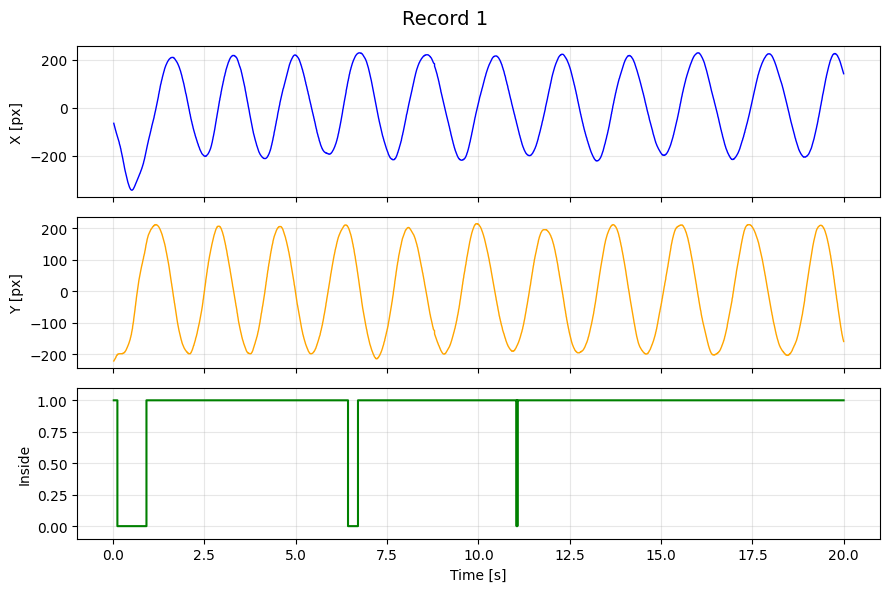

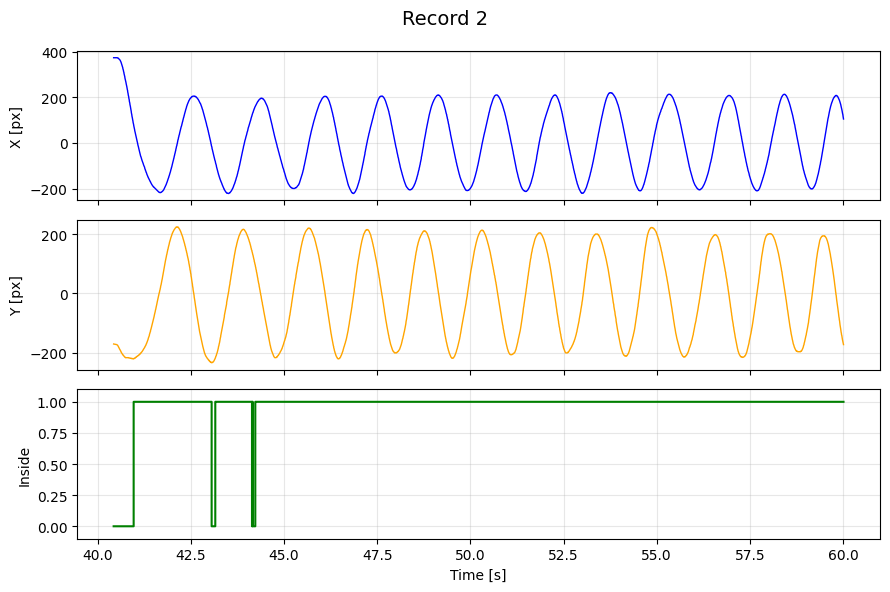

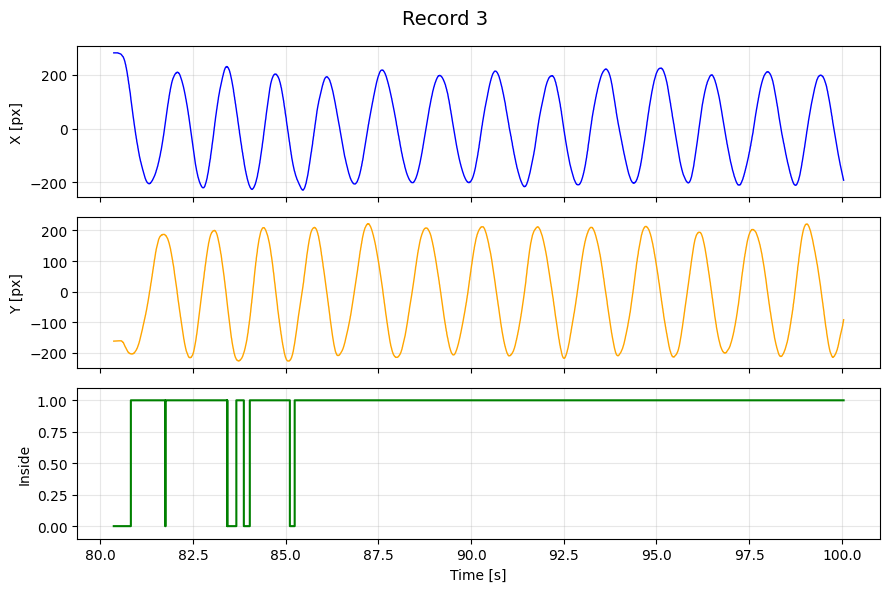

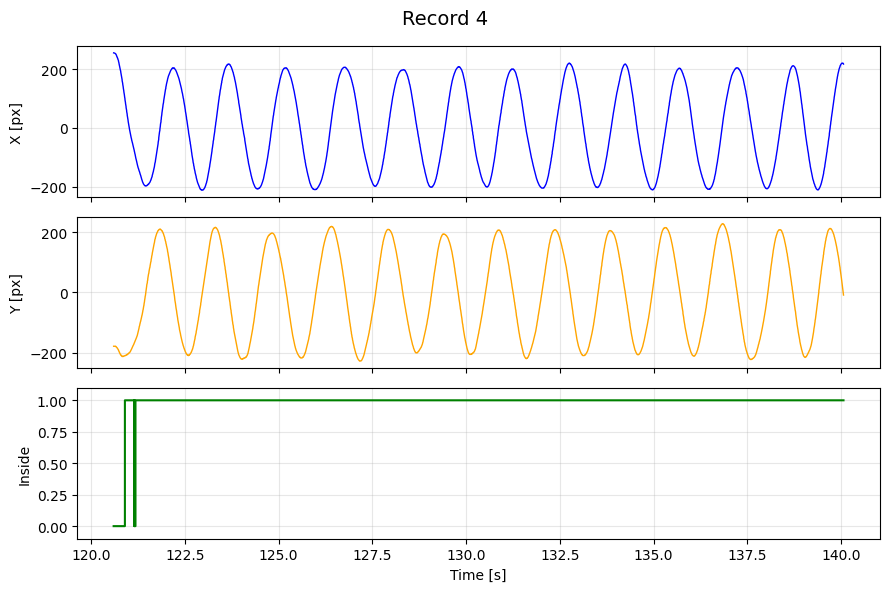

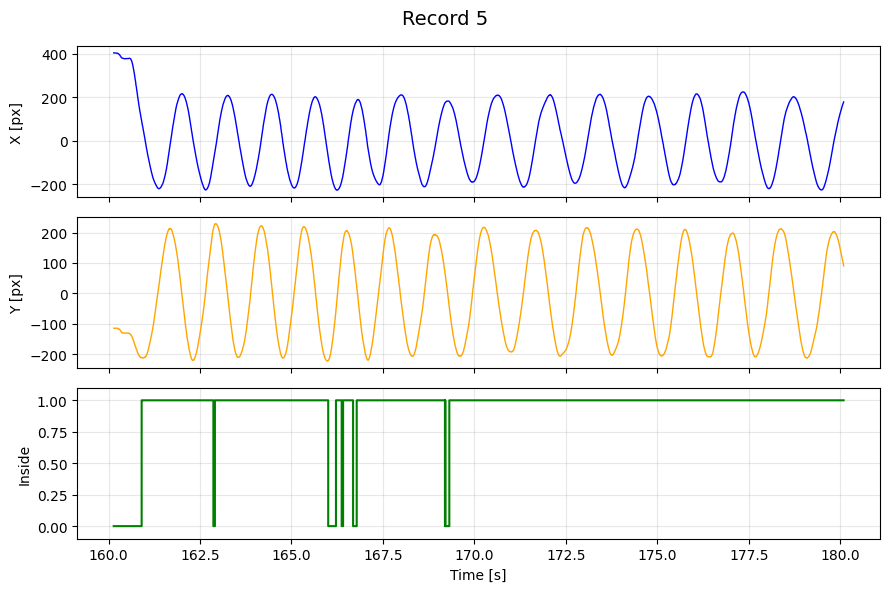


Computed statistics:
   Var    , nLaps ,       Re ,       Te ,   error ,  MT/lap , IDe/lap ,       Be ,     IPe
  unit   ,   lap ,    pixel ,    pixel ,       % ,   s/lap ,   ratio ,    ratio ,   ratio
Theory  ,  1.00 ,   209.50 ,    47.00 ,    3.88 ,         ,         ,     1.00 ,        
Rec001  , 10.84 ,   213.86 ,    91.79 ,   96.11 ,    1.84 ,   14.64 ,     1.95 ,    7.94
Rec002  , 11.97 ,   209.85 ,    34.46 ,   99.27 ,    1.59 ,   38.27 ,     0.73 ,   24.04
Rec003  , 13.26 ,   209.43 ,    42.42 ,   97.19 ,    1.45 ,   31.02 ,     0.90 ,   21.40
Rec004  , 12.83 ,   209.46 ,    37.14 ,   99.87 ,    1.49 ,   35.43 ,     0.79 ,   23.72
Rec005  , 14.74 ,   210.89 ,    43.88 ,   97.17 ,    1.30 ,   30.20 ,     0.93 ,   23.20

Processing complete.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# =============================================================================
# CONFIG / CONSTANTS
# =============================================================================

TE_MULTIPLIER = 4.1326            # Empirical: Te = TE_MULTIPLIER * std(radial, ddof=1)
ENABLE_PLOTS = True               # Set False to skip plotting
PRINT_DIAGNOSTICS = True          # Set False to suppress diagnostic prints
MIN_REQUIRED_COLUMNS = 4          # time, x, y, insideFlag

# Relative data dir (works if notebook inside notebooks/)
DATA_DIR_CANDIDATES = [
    Path("..") / "data",
    Path("./data"),
    Path.cwd() / "data"
]

DATA_FILE_NAME = "001MoDe_R1.csv"
MARKER_FILE_NAME = "001MoDe_R1.marker.csv"

# =============================================================================
# PATH RESOLUTION
# =============================================================================

def resolve_data_dir(candidates: List[Path]) -> Path:
    for p in candidates:
        if p.exists() and p.is_dir():
            return p
    raise FileNotFoundError(f"Could not locate data directory among: {candidates}")

DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)
CSV_PATH = DATA_DIR / DATA_FILE_NAME
MARKER_PATH = DATA_DIR / MARKER_FILE_NAME

# =============================================================================
# METADATA / MARKERS
# =============================================================================

def load_task_parameters(fname: Path) -> Dict[str, float]:
    """
    Parse first line of raw CSV for task parameters.
    Expected format: key value;key value;...
    """
    with open(fname, "r", encoding="utf-8") as f:
        first_line = f.readline().strip()
    params: Dict[str, float] = {}
    for entry in first_line.split(";"):
        tokens = entry.split()
        if len(tokens) != 2:
            continue
        k, v = tokens
        try:
            params[k] = float(v)
        except ValueError:
            continue
    required = ["centerX", "centerY", "taskRadius", "taskTolerance"]
    missing = [r for r in required if r not in params]
    if missing:
        raise ValueError(f"Missing required metadata fields: {missing}")
    return params

def read_markers(fname: Path) -> Dict[str, np.ndarray]:
    """
    Read marker file, handle multiline labels (blank line terminates).
    """
    markers = {
        "time_stamp": np.array([], dtype=float),
        "label": np.array([], dtype=str),
        "fname": str(fname)
    }

    def add(ts: float, lab: str):
        markers["time_stamp"] = np.append(markers["time_stamp"], ts)
        markers["label"]      = np.append(markers["label"], lab)

    with open(fname, "r", encoding="utf-8") as f:
        # Skip header block until empty line
        for line in f:
            if line.strip() == "":
                break
        multiline_mode = False
        multiline_ts = np.nan
        multiline_label = ""
        for line in f:
            raw = line.rstrip("\n")
            if multiline_mode:
                if raw.strip() == "":
                    add(multiline_ts, multiline_label.rstrip("\n"))
                    multiline_mode = False
                else:
                    multiline_label += raw + "\n"
                continue
            parts = raw.split(",")
            if len(parts) < 3:
                continue
            # parts[1] = timestamp, parts[2] = label (can be empty to start multiline)
            try:
                ts = float(parts[1])
            except ValueError:
                continue
            lab = parts[2]
            if lab == "":
                multiline_mode = True
                multiline_ts = ts
                multiline_label = ""
            else:
                add(ts, lab)
        if multiline_mode:
            add(multiline_ts, multiline_label.rstrip("\n"))

    if len(markers["time_stamp"]) == 0:
        raise ValueError(f"No markers parsed from {fname}")
    # Strip accidental whitespace
    markers["label"] = np.char.strip(markers["label"])
    return markers

def extract_record_intervals(markers: Dict, t0: float) -> List[Tuple[float, float]]:
    ts  = markers["time_stamp"]
    lab = markers["label"]
    intervals = []
    current_rec_ts = None
    for timestamp, label in zip(ts, lab):
        if "DoRecord" in label:
            current_rec_ts = timestamp
        elif "DoPause" in label and current_rec_ts is not None:
            start = (current_rec_ts - t0) / 1000.0
            end   = (timestamp - t0) / 1000.0
            if end > start:
                intervals.append((start, end))
            current_rec_ts = None
        # Stop early if label contains "RecordDone=6" (all done):
        if "RecordDone=" in label and "ToDo=" in label:
            try:
                done = int(label.split("RecordDone=")[1].split()[0])
                todo = int(label.split("ToDo=")[1].split()[0])
                if done >= todo:
                    break
            except Exception:
                pass
    if len(intervals) == 0:
        raise ValueError("No valid intervals parsed.")
    return intervals

# =============================================================================
# DATA LOADING
# =============================================================================

def is_numeric_line(line: str) -> bool:
    """
    Relaxed numeric check: require first 4 columns convertible to float.
    """
    parts = line.strip().split(",")
    if len(parts) < MIN_REQUIRED_COLUMNS:
        return False
    try:
        for i in range(4):
            float(parts[i])
        return True
    except ValueError:
        return False

def load_raw_data(fname: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load numeric portion of the CSV (skips metadata/header lines).
    Returns (time_ms, x, y, inside_flag).
    """
    with open(fname, "r", encoding="utf-8") as f:
        lines = f.readlines()
    numeric = [ln for ln in lines if is_numeric_line(ln)]
    if len(numeric) == 0:
        raise ValueError("No numeric lines retained. Check CSV format.")
    data = np.loadtxt(StringIO("".join(numeric)), delimiter=",")
    if data.ndim == 1:
        data = data.reshape(1, -1)
    if data.shape[1] < MIN_REQUIRED_COLUMNS:
        raise ValueError(f"Data has {data.shape[1]} columns (< {MIN_REQUIRED_COLUMNS} required).")
    time_ms = data[:, 0]
    x       = data[:, 1]
    y       = data[:, 2]
    inside  = data[:, 3].astype(bool)
    return time_ms, x, y, inside

# =============================================================================
# METRICS
# =============================================================================

def compute_metrics(
    t: np.ndarray,
    x: np.ndarray,
    y: np.ndarray,
    dist: np.ndarray,
    inside: np.ndarray,
    task_tolerance: float
) -> Optional[Dict[str, float]]:
    """
    Compute circular steering metrics after first inside event.
    """
    idx_inside = np.where(inside)[0]
    if len(idx_inside) == 0:
        return None
    start_idx = idx_inside[0]

    t_f      = t[start_idx:]
    x_f      = x[start_idx:]
    y_f      = y[start_idx:]
    dist_f   = dist[start_idx:]
    inside_f = inside[start_idx:]

    Re = np.mean(dist_f)
    Te = TE_MULTIPLIER * np.std(dist_f, ddof=1)

    theta = np.arctan2(y_f, x_f)
    dtheta = np.diff(theta)
    # Phase unwrap
    dtheta = (dtheta + np.pi) % (2 * np.pi) - np.pi
    abs_dtheta = np.abs(dtheta)

    if len(abs_dtheta) == 0:
        # Not enough movement samples to compute angular stats
        return {
            "Re": Re, "Te": Te, "error": np.nan,
            "nLaps": 0.0, "MT": np.nan, "IDe": np.nan,
            "Be": Te / task_tolerance if task_tolerance > 0 else np.nan,
            "IPe": np.nan
        }

    outside_segments = ~inside_f[:-1]
    total_angle = np.sum(abs_dtheta)
    outside_angle = np.sum(abs_dtheta[outside_segments])
    inside_percentage = 100 - (outside_angle / total_angle * 100) if total_angle > 0 else 0

    signed_total_angle = np.sum(dtheta)
    nLaps = signed_total_angle / (2 * np.pi)

    duration = t_f[-1] - t_f[0]
    MT = duration / abs(nLaps) if nLaps != 0 else np.nan

    IDe = (2 * np.pi * Re) / Te if Te > 0 else np.nan
    Be  = Te / task_tolerance if task_tolerance > 0 else np.nan
    IPe = IDe / MT if (MT > 0 and not np.isnan(MT) and not np.isnan(IDe)) else np.nan

    return {
        "Re": Re,
        "Te": Te,
        "error": inside_percentage,
        "nLaps": nLaps,
        "MT": MT,
        "IDe": IDe,
        "Be": Be,
        "IPe": IPe
    }

# =============================================================================
# DIAGNOSTICS
# =============================================================================

def diagnostics(time_ms, x, y, inside, markers):
    if not PRINT_DIAGNOSTICS:
        return
    print("\n--- Diagnostics ---")
    print(f"Raw samples: {len(time_ms)}")
    print(f"Time ms min/max: {time_ms.min():.0f} / {time_ms.max():.0f}")
    print(f"Inside flag distribution: {np.unique(inside, return_counts=True)}")
    print(f"Markers count: {len(markers['time_stamp'])}")
    print("First 5 markers:", list(zip(markers["time_stamp"][:5], markers["label"][:5])))

# =============================================================================
# MAIN PIPELINE
# =============================================================================

def main():
    print(f"Using data directory: {DATA_DIR}")

    # Load parameters
    params = load_task_parameters(CSV_PATH)
    centerX   = params["centerX"]
    centerY   = params["centerY"]
    taskRad   = params["taskRadius"]
    taskTol   = params["taskTolerance"]

    print(f"Metadata → center=({centerX:.1f},{centerY:.1f}) taskRadius={taskRad:.1f} taskTolerance={taskTol:.1f}")

    # Load raw trajectory
    time_ms, x, y, inside = load_raw_data(CSV_PATH)

    # Load markers
    markers = read_markers(MARKER_PATH)
    do_record_times = markers["time_stamp"][np.char.startswith(markers["label"], "DoCycleChange:DoRecord")]

    if len(do_record_times) == 0:
        raise ValueError("No DoRecord markers found.")

    t0 = do_record_times[0]
    time_s = (time_ms - t0) / 1000.0

    # Center coordinates
    x_c = x - centerX
    y_c = y - centerY
    dist = np.sqrt(x_c**2 + y_c**2)

    diagnostics(time_ms, x_c, y_c, inside, markers)

    # Extract intervals (fallback to hardcoded if fails)
    try:
        record_intervals = extract_record_intervals(markers, t0)
    except Exception as e:
        print(f"Interval extraction failed ({e}); falling back to hardcoded intervals.")
        record_intervals = [
            (0.022, 20.004),
            (40.429, 60.018),
            (80.371, 100.050),
            (120.608, 140.069),
            (160.146, 180.098),
        ]

    print(f"\nRecording intervals ({len(record_intervals)}):")
    for i, (a, b) in enumerate(record_intervals):
        mask_len = np.count_nonzero((time_s >= a) & (time_s <= b))
        print(f"  Rec {i+1}: {a:.3f}s → {b:.3f}s (dur {b-a:.3f}s) points={mask_len}")

    # Optional plots
    if ENABLE_PLOTS:
        print("\nPlotting per-record time series...")
        for i, (start, end) in enumerate(record_intervals):
            mask = (time_s >= start) & (time_s <= end)
            t_seg = time_s[mask]
            if len(t_seg) == 0:
                print(f"Skip plot Rec {i+1}: empty interval.")
                continue
            x_seg = x_c[mask]
            y_seg = y_c[mask]
            inside_seg = inside[mask].astype(int)

            fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
            fig.suptitle(f"Record {i+1}", fontsize=14)

            axs[0].plot(t_seg, x_seg, 'b-', lw=1)
            axs[0].set_ylabel("X [px]")
            axs[0].grid(alpha=0.3)

            axs[1].plot(t_seg, -y_seg, color='orange', lw=1)  # inverted Y for standard cartesian feel
            axs[1].set_ylabel("Y [px]")
            axs[1].grid(alpha=0.3)

            axs[2].step(t_seg, inside_seg, where='post', color='green')
            axs[2].set_ylabel("Inside")
            axs[2].set_xlabel("Time [s]")
            axs[2].set_ylim(-0.1, 1.1)
            axs[2].grid(alpha=0.3)

            plt.tight_layout()
            plt.show()

    # Metrics table header
    print("\nComputed statistics:")
    print(f"   {'Var':<6} , {'nLaps':>5} , {'Re':>8} , {'Te':>8} , {'error':>7} , {'MT/lap':>7} , {'IDe/lap':>7} , {'Be':>8} , {'IPe':>7}")
    print(f"  {'unit':<6} , {'lap':>5} , {'pixel':>8} , {'pixel':>8} , {'%':>7} , {'s/lap':>7} , {'ratio':>7} , {'ratio':>8} , {'ratio':>7}")
    print(f"{'Theory':<7} , {1.00:5.2f} , {taskRad:8.2f} , {taskTol:8.2f} , {3.88:7.2f} , {'':>7} , {'':>7} , {1.00:8.2f} , {'':>7}")

    for i, (start, end) in enumerate(record_intervals):
        mask = (time_s >= start) & (time_s <= end)
        t_rec   = time_s[mask]
        x_rec   = x_c[mask]
        y_rec   = y_c[mask]
        dist_rec = dist[mask]
        inside_rec = inside[mask]

        if len(t_rec) == 0:
            print(f"{'Rec'+str(i+1).zfill(3):<7} , {0:5.2f} , {0:8.2f} , {0:8.2f} , {np.nan:7.2f} , {np.nan:7.2f} , {np.nan:7.2f} , {0:8.2f} , {0:7.2f}")
            continue

        metrics = compute_metrics(t_rec, x_rec, y_rec, dist_rec, inside_rec, taskTol)
        if metrics is None:
            print(f"Warning: Rec{i+1:03d} - cursor never entered target")
            continue

        print(f"{'Rec'+str(i+1).zfill(3):<7} , "
              f"{metrics['nLaps']:5.2f} , {metrics['Re']:8.2f} , {metrics['Te']:8.2f} , "
              f"{metrics['error']:7.2f} , {metrics['MT']:7.2f} , {metrics['IDe']:7.2f} , "
              f"{metrics['Be']:8.2f} , {metrics['IPe']:7.2f}")

    print("\nProcessing complete.")

# Run pipeline
main()